# Hf-Nd isotope terrane mapping

**Cluster D: Zircons + tectonic-setting predictors.**

Hf and Nd isotopes are the workhorse tracers for classifying continental crust as either **juvenile** — freshly extracted from the mantle — or **evolved** — reworked from older crustal material. εHf(t) and εNd(t) values close to zero (chondritic) or positive indicate juvenile crust; strongly negative values indicate evolved crust that has spent significant time as continental material before being re-melted. The Nd depleted-mantle model age T_DM_Nd estimates when the crust in question was originally extracted from the mantle. Mapping these three quantities across a continent yields a **crustal architecture map**: a spatial view of when each terrane was born and how much it has been reworked since.

This is the workflow pioneered by Bennett & DePaolo (1987) for southwest USA, Payne, Barovich & Hand (2006) for Australia, and generalised globally by Roberts & Spencer (2015).

## What this notebook produces

1. **§3 — Present-day εHf(t) sample map.** All \~80 samples in the bundled compilation plotted at their present-day coordinates, colour-coded by εHf(t) on a red-blue diverging scale (red = evolved, blue = juvenile). Shows the classic pattern: cratonic interiors evolved (red), margins and orogenic belts juvenile (blue).
2. **§4 — Nd model-age T_DM map.** Same samples coloured by depleted-mantle model age — the age at which the crustal source was extracted from the mantle. This is the *primary* Bennett & DePaolo (1987) "terrane mapping" quantity.
3. **§5 — Paleogeographic reconstruction for one window.** Samples with zircon crystallisation ages in a chosen window (e.g. 600-500 Ma) reconstructed to their formation age on a Z22 paleogeographic reconstruction. Shows *where* the juvenile Neoproterozoic crust of the Arabian-Nubian Shield, CAOB, Damara etc. was actually being generated at that time.
4. **§6 — Global Hf evolution diagram.** εHf(t) vs zircon crystallisation age scatter, with the CHUR (chondritic) and DM (depleted-mantle) evolution lines overplotted. Every sample is placed in that global diagram — the classic Belousova / Roberts & Spencer visualisation.

## Learning objectives

- Load a point compilation of εHf(t) + T_DM values, standardised across major crustal provinces.
- Colour a paleo-map by a continuous isotopic quantity using pyGMT's WYSIWYG cpt.
- Reconstruct point samples to their crystallisation age (per-sample, not common-age — same pattern as T60).
- Overplot analytical evolution lines (CHUR, DM) on a scatter diagram.

## Prerequisites and runtime

- Bundled data at `data/hf_nd_isotopes/hf_nd_curated.csv` — 80 samples spanning Eoarchean to Miocene. Full compilations (\~10k+ samples) via Belousova 2010, Roberts & Spencer 2015 supplements (see Sources).
- Python: `gplately`, `pygplates`, `pygmt`, `pandas`, `numpy`, `matplotlib`.
- Runtime: \~30 s.


## Environment + imports


In [1]:
from pathlib import Path
import os, sys
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  pygmt       v0.18.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygplates   1.0.0


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME              = "Cao2024"  # 0-1.8 Ga coverage — matches T09-T11 zircon workflow
ANCHOR_PLATE_ID         = 0                    # Cao 2024 default anchor

# The paleogeographic reconstruction in §5 shows samples with zircon crystallisation ages inside
# this window, reconstructed to their formation age. Default: 500-700 Ma window
# because it captures the birth of the Arabian-Nubian Shield, CAOB, Delamerian,
# Kunlun and Cadomian juvenile belts — the classic Neoproterozoic-to-Cambrian
# juvenile crust production peak.
PALEO_WINDOW_MIN_MA     = 500
PALEO_WINDOW_MAX_MA     = 700
PALEO_TARGET_MA         = 600                  # continents drawn at this age

# Colour ranges
EPS_HF_RANGE            = [-10, 10, 1]         # symmetric around CHUR
T_DM_RANGE_MA           = [500, 4000, 100]     # crustal-formation-age domain

# Isotope catalog
CATALOG_CSV             = Path("data/hf_nd_isotopes/hf_nd_curated.csv")

# CHUR + DM reference-line values (Bouvier et al. 2008 for CHUR;
# Griffin et al. 2000 for depleted-mantle-Hf reference)
LAMBDA_176LU            = 1.867e-11            # per year
CHUR_176HF_177HF_TODAY  = 0.282785
CHUR_176LU_177HF_TODAY  = 0.0336
DM_176HF_177HF_TODAY    = 0.28325
DM_176LU_177HF_TODAY    = 0.0388
# ============================================================================
print(f"  model:        {MODEL_NAME}")
print(f"  paleo target: {PALEO_TARGET_MA} Ma")
print(f"  age window:   {PALEO_WINDOW_MIN_MA}-{PALEO_WINDOW_MAX_MA} Ma")


  model:        Cao2024
  paleo target: 600 Ma
  age window:   500-700 Ma


## 1. Load the compilation


In [3]:
df = pd.read_csv(CATALOG_CSV, comment="#")
print(f"  {len(df)} samples loaded")
print(f"  age range: {df['zircon_age_ma'].min():.0f} - {df['zircon_age_ma'].max():.0f} Ma")
print(f"  εHf(t) range: {df['epsilon_hf_t'].min():.1f} to {df['epsilon_hf_t'].max():.1f}")
print(f"  T_DM range: {df['t_dm_nd_ma'].min():.0f} - {df['t_dm_nd_ma'].max():.0f} Ma")
print(f"  provinces: {df['tectonic_province'].nunique()} distinct")
df.head(3)


  82 samples loaded
  age range: 5 - 3800 Ma
  εHf(t) range: -4.0 to 9.0
  T_DM range: 20 - 4100 Ma
  provinces: 23 distinct


,name,sample_lat,sample_lon,zircon_age_ma,epsilon_hf_t,t_dm_nd_ma,tectonic_province,notes
0,Yilgarn Craton (Kalgoorlie),-30.7,121.5,2700,-3.0,3300,Archean craton,evolved Late Archean granite-greenstone
1,Yilgarn Craton (Narryer),-27.0,116.0,3600,-1.0,3800,Archean craton,detrital Jack Hills zircons early crust
2,Pilbara Craton (Marble Bar),-21.2,119.7,3450,2.0,3550,Archean craton,juvenile Paleoarchean TTG


## 2. Plate model


In [4]:
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_layer("Coastlines"),
    plot_engine=gplately.PygmtPlotEngine(),
    continents=model.get_layer("ContinentalPolygons"),
    time=PALEO_TARGET_MA,
    anchor_plate_id=ANCHOR_PLATE_ID,
)
print(f"  {MODEL_NAME} loaded")

# Assign present-day plate IDs
pts = gplately.Points(
    plate_reconstruction=recon,
    lons=df["sample_lon"].values, lats=df["sample_lat"].values,
    time=0, anchor_plate_id=ANCHOR_PLATE_ID,
)
df["plate_id"] = pts.plate_id
print(f"  plate IDs assigned")


  Cao2024 loaded
  plate IDs assigned


## 3. Present-day εHf(t) map

Colour every sample by its εHf(t). Red = evolved (negative), blue = juvenile (positive), white = chondritic (0).


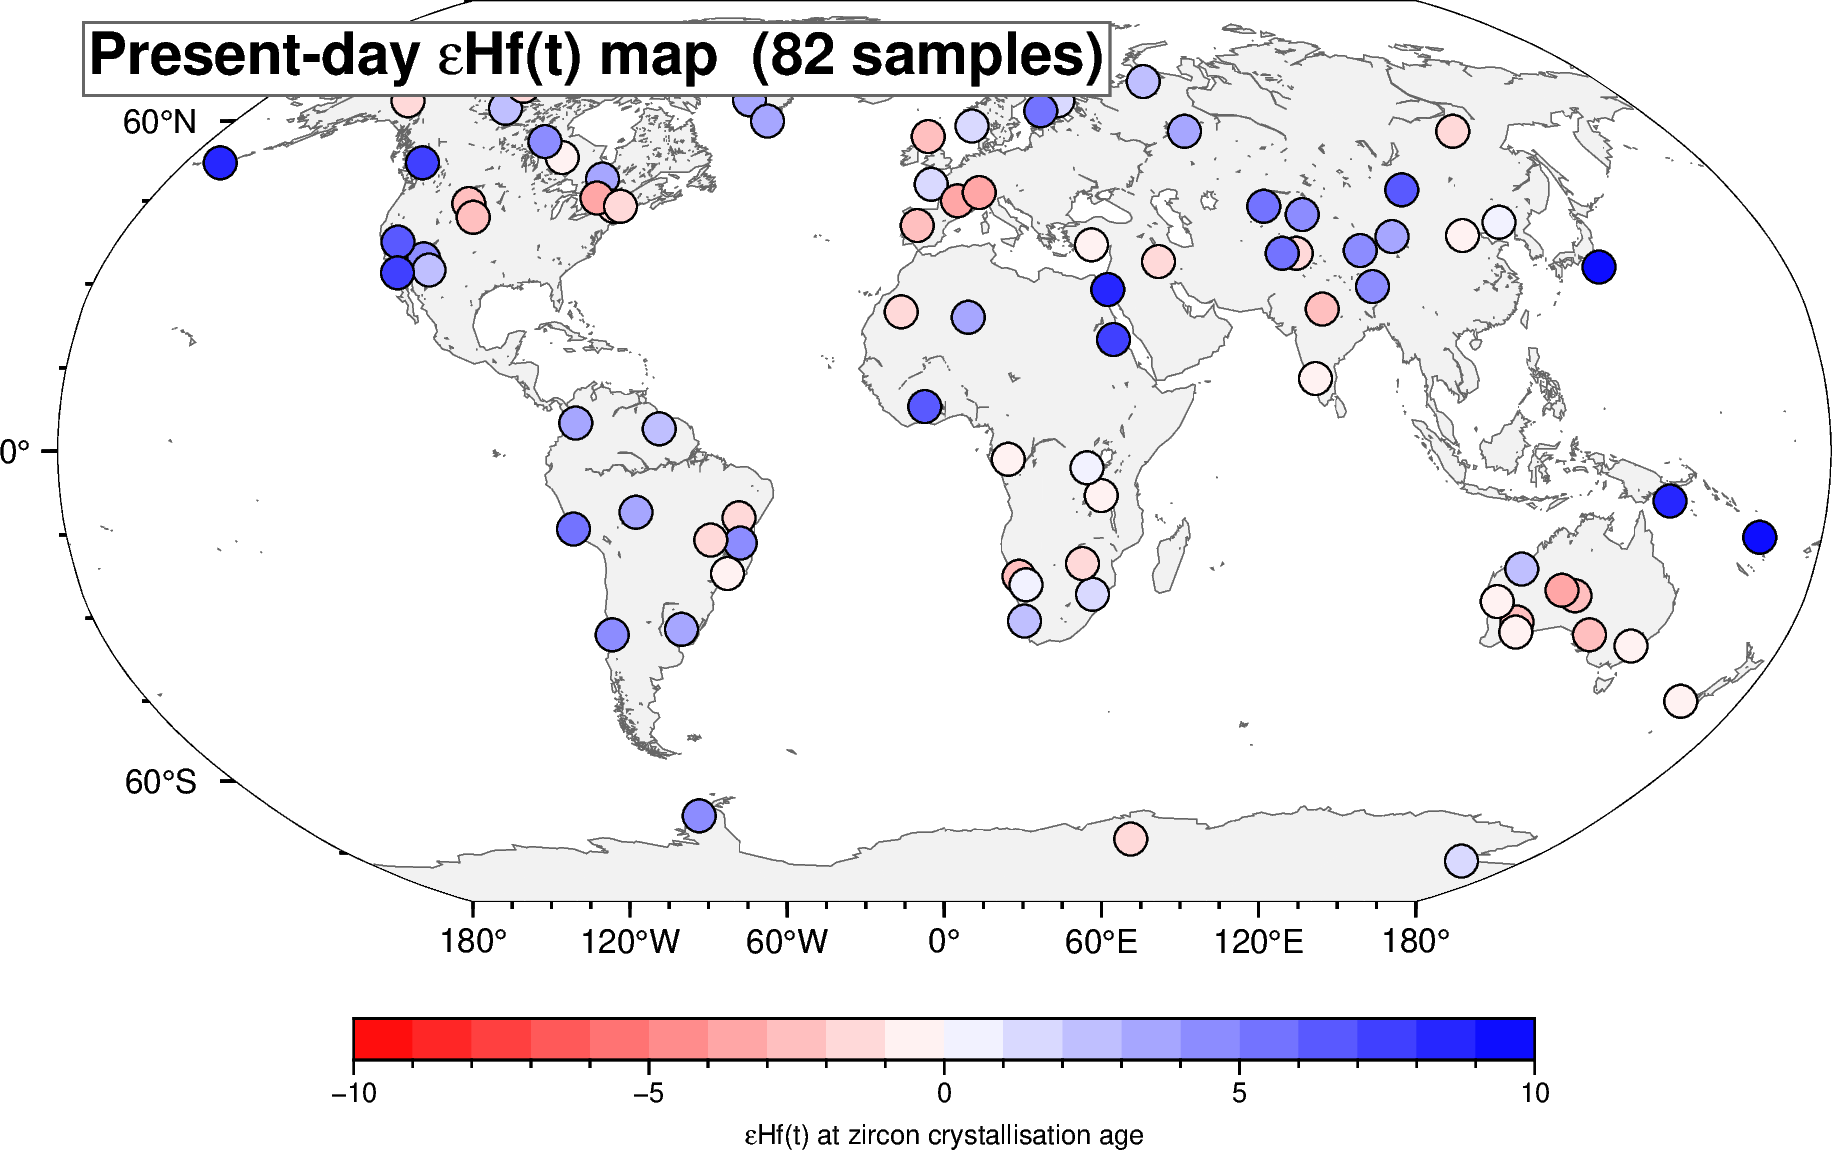

In [5]:
fig = pygmt.Figure()
REGION, PROJ = [-180, 180, -90, 90], "N15c"
fig.basemap(region=REGION, projection=PROJ, frame="af")
fig.coast(region=REGION, projection=PROJ, land="gray95", water="white", shorelines="0.25p,gray40")

# Diverging cpt — red for evolved εHf<0, blue for juvenile εHf>0
pygmt.makecpt(cmap="polar", series=EPS_HF_RANGE, background="o", reverse=True)
fig.plot(x=df["sample_lon"], y=df["sample_lat"],
         style="c0.28c", fill=df["epsilon_hf_t"], cmap=True, pen="0.4p,black",
         region=REGION, projection=PROJ)

fig.colorbar(position="JBC+w10c/0.35c+h+o0/1c",
             frame=["a5f1", "x+lεHf(t) at zircon crystallisation age"])
fig.text(text=f"Present-day εHf(t) map  ({len(df)} samples)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


### How to read this map

- **Deep red** — strongly evolved crust with εHf(t) < −5. Interpretation: this sample's zircon crystallised from a melt whose source had been isolated from the depleted mantle for hundreds of millions of years. Classic examples: Archean cratonic granulite terranes, Mesoproterozoic Grenville reworked rocks, Variscan Massif Central, Delamerian Orogen.
- **Deep blue** — strongly juvenile crust with εHf(t) > +5. Interpretation: freshly extracted from the depleted mantle at close to the zircon crystallisation age. Classic examples: Cordilleran arcs (Sierra Nevada, Peninsular Ranges, Andean coastal), intra-oceanic arcs (Vanuatu, Aleutian, Izu-Bonin, Kohistan), Arabian-Nubian Shield.
- **White / near-zero** — chondritic. Mixed juvenile-reworked origin, or older juvenile crust that has spent moderate time evolving.

**Watch for**

- The Cordilleran belt (blue) — Alaska to Chile is a nearly continuous juvenile arc chain.
- The African / South American cratonic cores (red) — Kaapvaal, Zimbabwe, Congo, Sao Francisco, West African.
- The Grenville belt across North America into Sveconorwegian Norway (mostly red-orange) — reworked ancient crust dominating Mesoproterozoic mountain building.
- The Arabian-Nubian Shield (deep blue at 30-35° N along the Red Sea) — the world's largest juvenile Neoproterozoic province.


## 4. Nd model-age T_DM map — the Bennett & DePaolo terrane view

Depleted-mantle Nd model age is *when* the crust in this sample was originally extracted from the mantle — irrespective of when its zircon crystallised. Two samples with the same zircon crystallisation age can have very different T_DM if one was crystallised from a juvenile melt and the other from re-melted old crust. Mapping T_DM defines **crustal-formation-age provinces** (Bennett & DePaolo 1987).


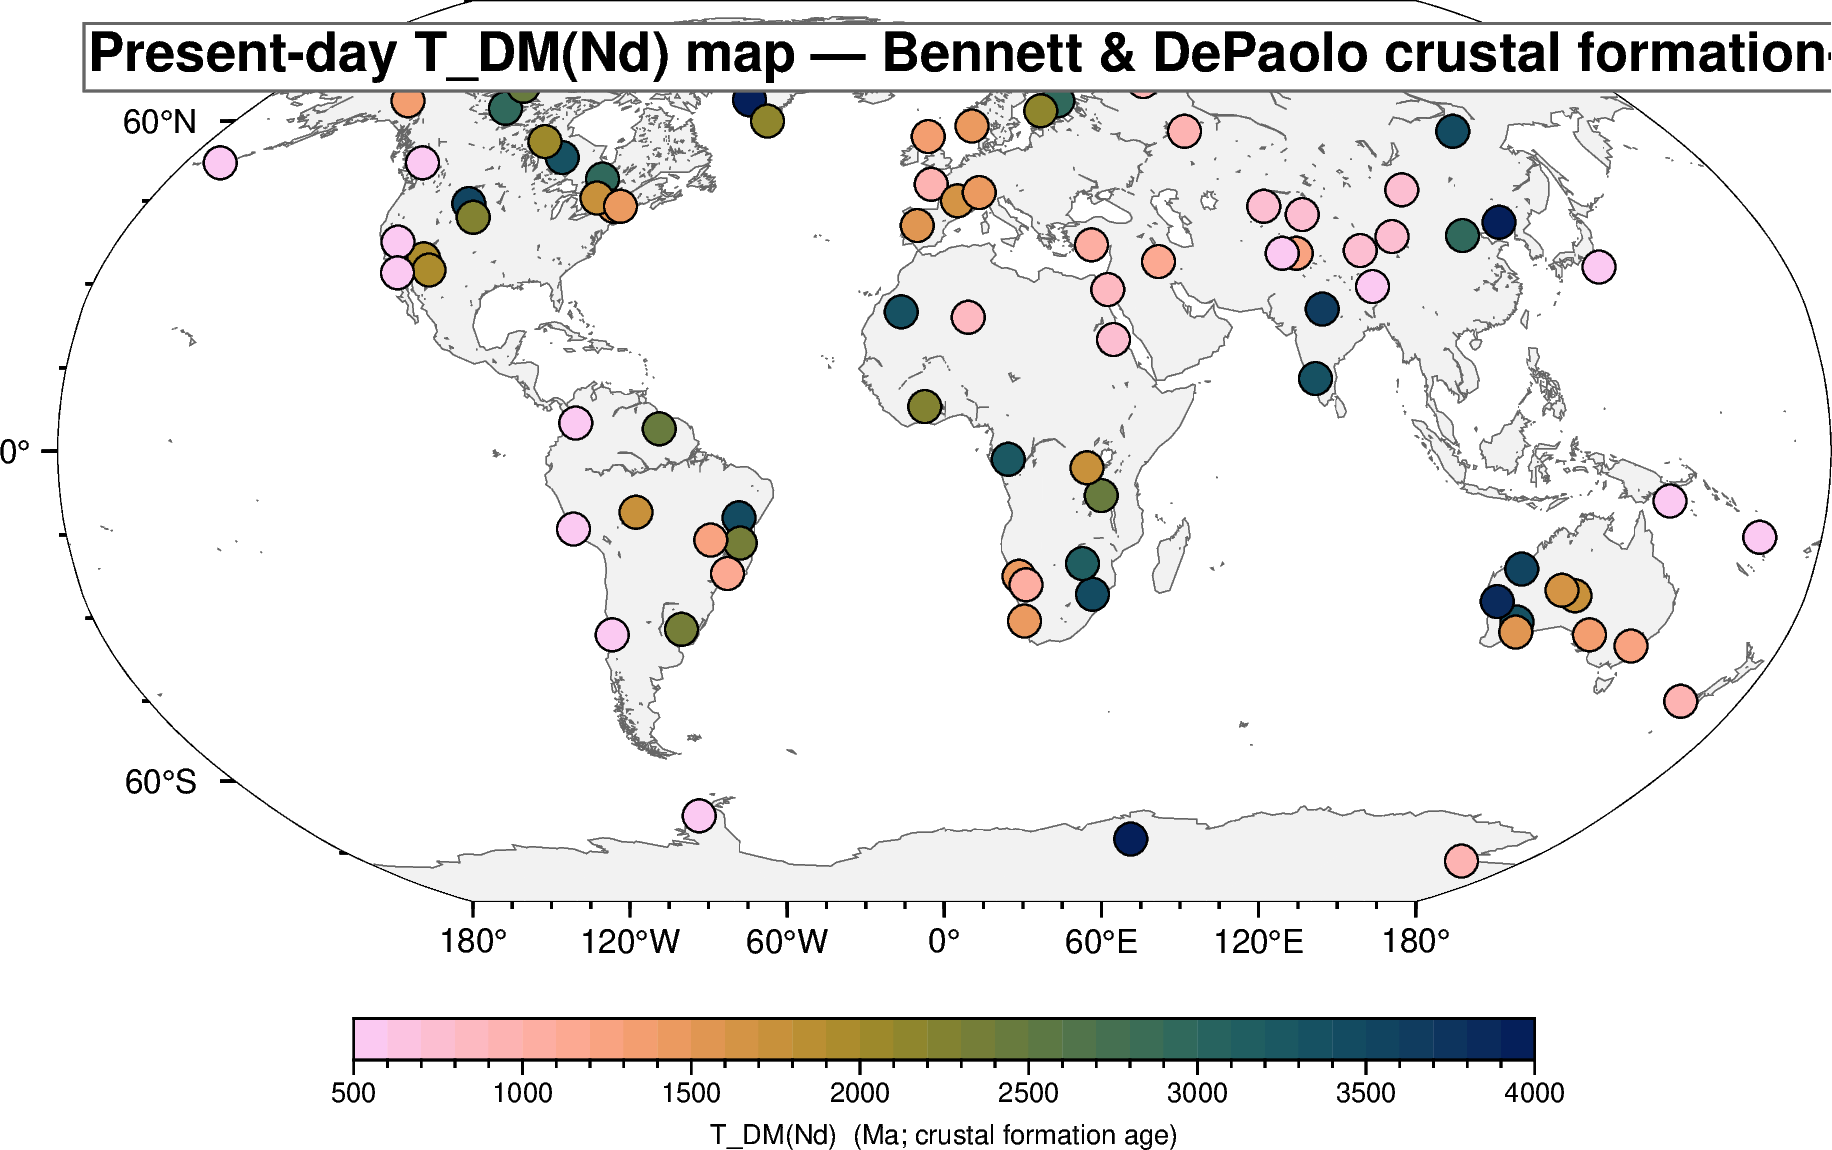

In [6]:
fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
fig.coast(region=REGION, projection=PROJ, land="gray95", water="white", shorelines="0.25p,gray40")

pygmt.makecpt(cmap="batlow", series=T_DM_RANGE_MA, background="o", reverse=True)
fig.plot(x=df["sample_lon"], y=df["sample_lat"],
         style="c0.28c", fill=df["t_dm_nd_ma"], cmap=True, pen="0.4p,black",
         region=REGION, projection=PROJ)

fig.colorbar(position="JBC+w10c/0.35c+h+o0/1c",
             frame=["a500f100", "x+lT_DM(Nd)  (Ma; crustal formation age)"])
fig.text(text="Present-day T_DM(Nd) map — Bennett & DePaolo crustal formation-age provinces",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="13p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


### How to read the T_DM map

- **Dark colours (T_DM > 3000 Ma)** — Archean cratonic cores. Jack Hills, Nuuk, Anshan, Napier.
- **Mid colours (T_DM ~ 1500-2500 Ma)** — Paleoproterozoic and Mesoproterozoic reworked provinces.
- **Light colours (T_DM < 1000 Ma)** — Neoproterozoic + Phanerozoic juvenile provinces. The characteristic signature of the Arabian-Nubian Shield, Cordilleran arcs, Aleutian-Izu-Bonin-Kohistan intra-oceanic arcs.

This is the classic terrane map — every point on a continent has a mantle-extraction age, and neighbouring points with similar T_DM values define a **crustal province** with a coherent history.


## 5. Paleogeographic reconstruction for the chosen age window

Reconstruct samples with zircon crystallisation ages in `[PALEO_WINDOW_MIN_MA, PALEO_WINDOW_MAX_MA]` to their formation age on the paleogeographic reconstruction at `PALEO_TARGET_MA`. Colour by εHf(t) so juvenile arcs appear blue and reworked belts appear red on the same paleogeographic reconstruction.


  11 samples in 500-700 Ma window
  11 reconstructable to 600 Ma


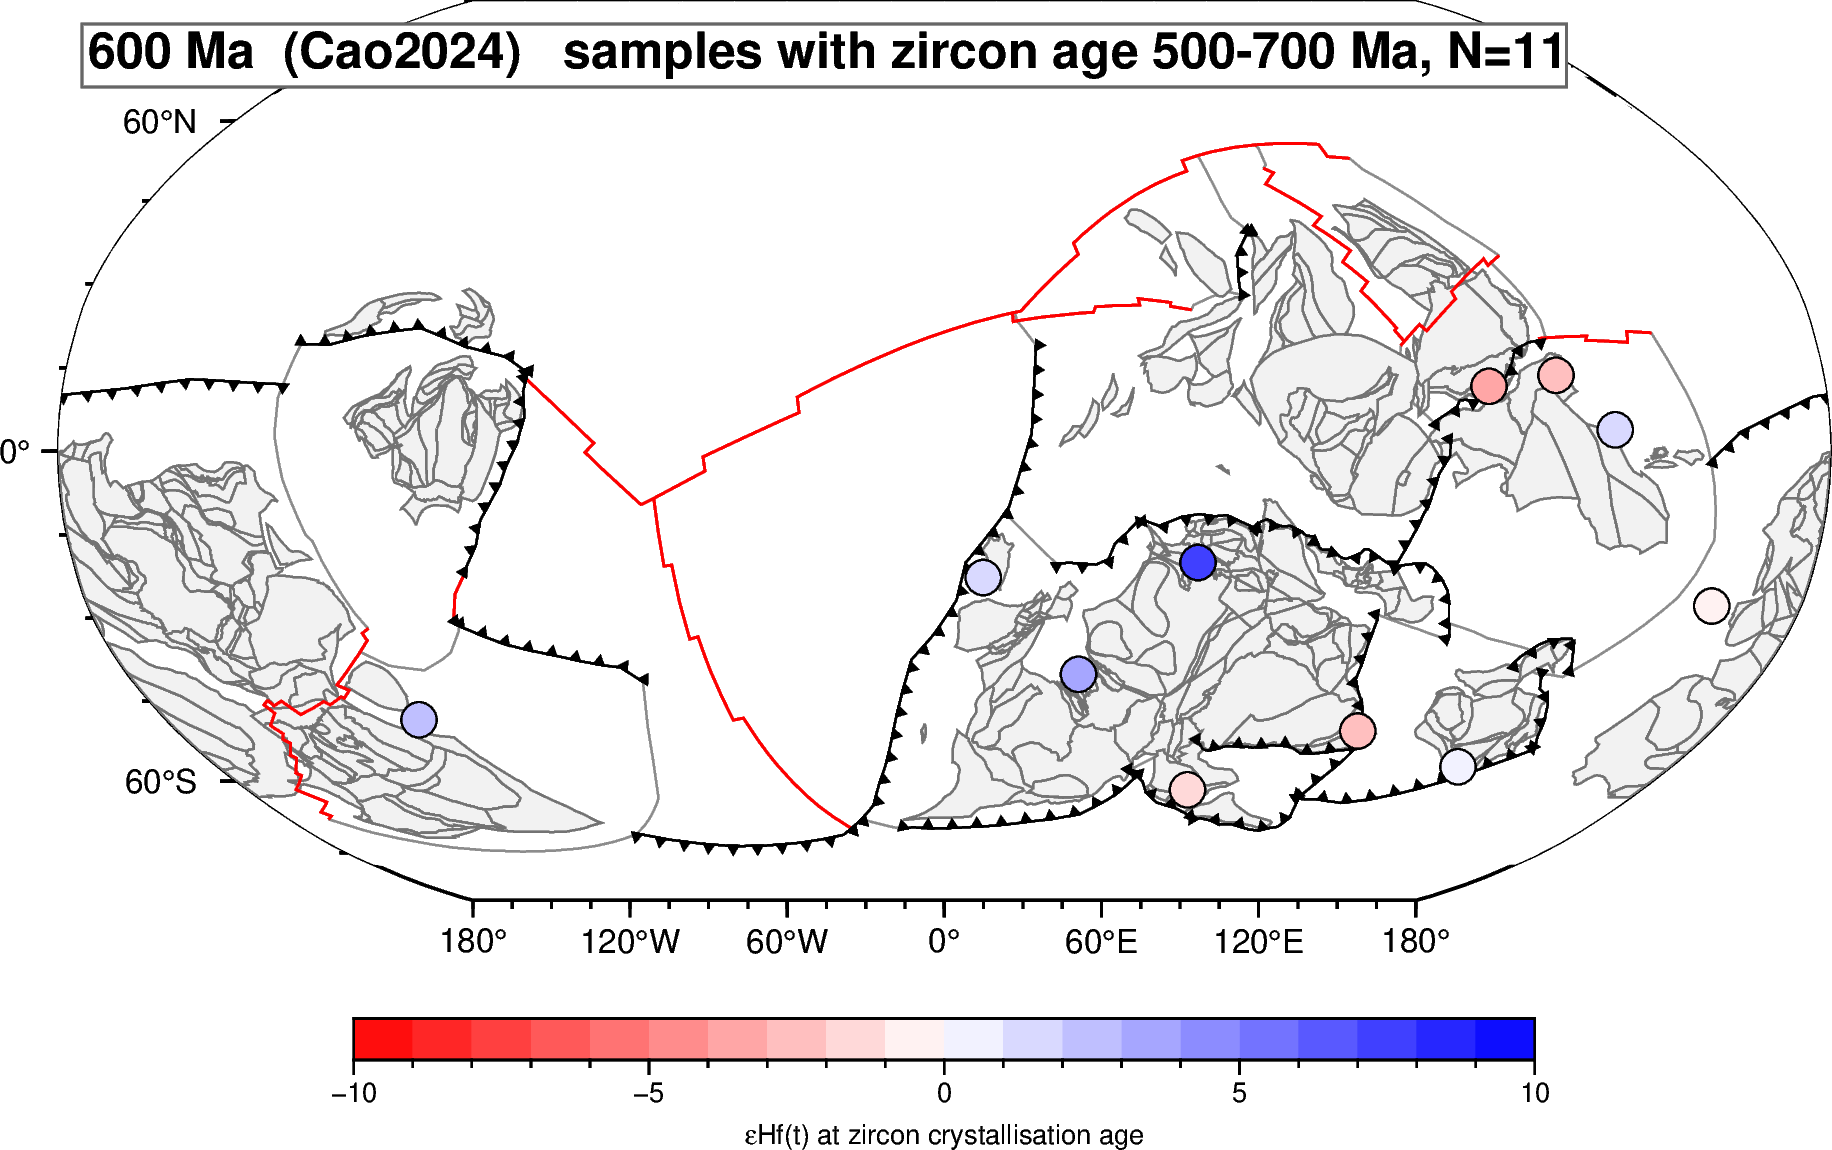

In [7]:
# Filter samples whose zircon crystallisation age lies inside the window,
# clipped to the plate model's coverage (Cao 2024 = 0-1.8 Ga).
window_df = df[(df["zircon_age_ma"] >= PALEO_WINDOW_MIN_MA) &
               (df["zircon_age_ma"] <= PALEO_WINDOW_MAX_MA) &
               (df["zircon_age_ma"] <= 1800)].copy()   # Cao 2024 coverage
print(f"  {len(window_df)} samples in {PALEO_WINDOW_MIN_MA}-{PALEO_WINDOW_MAX_MA} Ma window")

# Reconstruct each sample's PRESENT-DAY position to PALEO_TARGET_MA (not to
# the sample's own zircon age). This puts every dot on the SAME paleogeographic reconstruction
# reference age as the continents drawn from gplot. Reconstructing to a
# sample's own age would place dots on a differently-aged continent set
# and they would drift into the ocean.
if len(window_df) > 0:
    paleo_lons, paleo_lats = [], []
    for _, row in window_df.iterrows():
        try:
            _p = gplately.Points(
                plate_reconstruction=recon,
                lons=[row["sample_lon"]], lats=[row["sample_lat"]],
                time=0, plate_id=[int(row["plate_id"])],
                anchor_plate_id=ANCHOR_PLATE_ID,
            )
            rlons, rlats = _p.reconstruct(time=float(PALEO_TARGET_MA),
                                           return_array=True,
                                           anchor_plate_id=ANCHOR_PLATE_ID)
            paleo_lons.append(float(rlons[0])); paleo_lats.append(float(rlats[0]))
        except Exception:
            paleo_lons.append(np.nan); paleo_lats.append(np.nan)
    window_df["paleo_lon"], window_df["paleo_lat"] = paleo_lons, paleo_lats
    window_df = window_df.dropna(subset=["paleo_lon", "paleo_lat"])
    print(f"  {len(window_df)} reconstructable to {PALEO_TARGET_MA} Ma")

fig = pygmt.Figure()
gplot.time = PALEO_TARGET_MA
fig.basemap(region=REGION, projection=PROJ, frame="af")
fig.coast(region=REGION, projection=PROJ, water="white", shorelines=None)

try:
    # (engine now dispatched via gplately.PygmtPlotEngine on PlotTopologies)
    gplot.plot_all_topological_sections(fig, pen="0.5p,gray55")
    gplot.plot_continents(fig, fill="gray95", pen="0.5p,gray45")
    gplot.plot_ridges(fig, pen="0.6p,red")
    gplot.plot_subduction_teeth(fig, color="black")
except Exception:
    pass

if len(window_df) > 0:
    pygmt.makecpt(cmap="polar", series=EPS_HF_RANGE, background="o", reverse=True)
    fig.plot(x=window_df["paleo_lon"], y=window_df["paleo_lat"],
             style="c0.30c", fill=window_df["epsilon_hf_t"], cmap=True,
             pen="0.4p,black", region=REGION, projection=PROJ)
    fig.colorbar(position="JBC+w10c/0.35c+h+o0/1c",
                 frame=["a5f1", "x+lεHf(t) at zircon crystallisation age"])

fig.text(text=(f"{PALEO_TARGET_MA:.0f} Ma  ({MODEL_NAME})   "
               f"samples with zircon age {PALEO_WINDOW_MIN_MA}-{PALEO_WINDOW_MAX_MA} Ma, "
               f"N={len(window_df)}"),
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="12p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


### How to read the paleogeographic reconstruction

By plotting εHf(t) samples at their **crystallisation age** on the paleogeographic reconstruction of `PALEO_TARGET_MA`, we see the crustal-generation map at that time. For the default 500-700 Ma window at 600 Ma:

- **Northern Gondwana margin (Arabian-Nubian, Cadomian, Trans-Saharan)** should show a chain of blue (juvenile) dots — arc generation along the closing of the Mozambique / Iapetus oceans.
- **Interior Gondwana (Damara, Petermann, Brasilia, Ribeira)** — red dots (evolved reworked crust) — intracontinental orogenic reworking during Rodinia breakup and Gondwana assembly.
- **Cordilleran-style juvenile belts** — Kunlun, Qilian, CAOB — blue on the paleo-Asian side.


## 6. Global Hf evolution diagram

εHf(t) vs zircon crystallisation age scatter, with the two reference evolution lines:

- **CHUR** — chondritic uniform reservoir. εHf = 0 by construction.
- **DM** — depleted mantle. Evolved forward from `(176Hf/177Hf, 176Lu/177Hf) = (DM values today)` using the ¹⁷⁶Lu decay constant.

Every sample plots between these two envelopes. Samples close to the DM line are freshly juvenile; samples far below CHUR are strongly reworked.


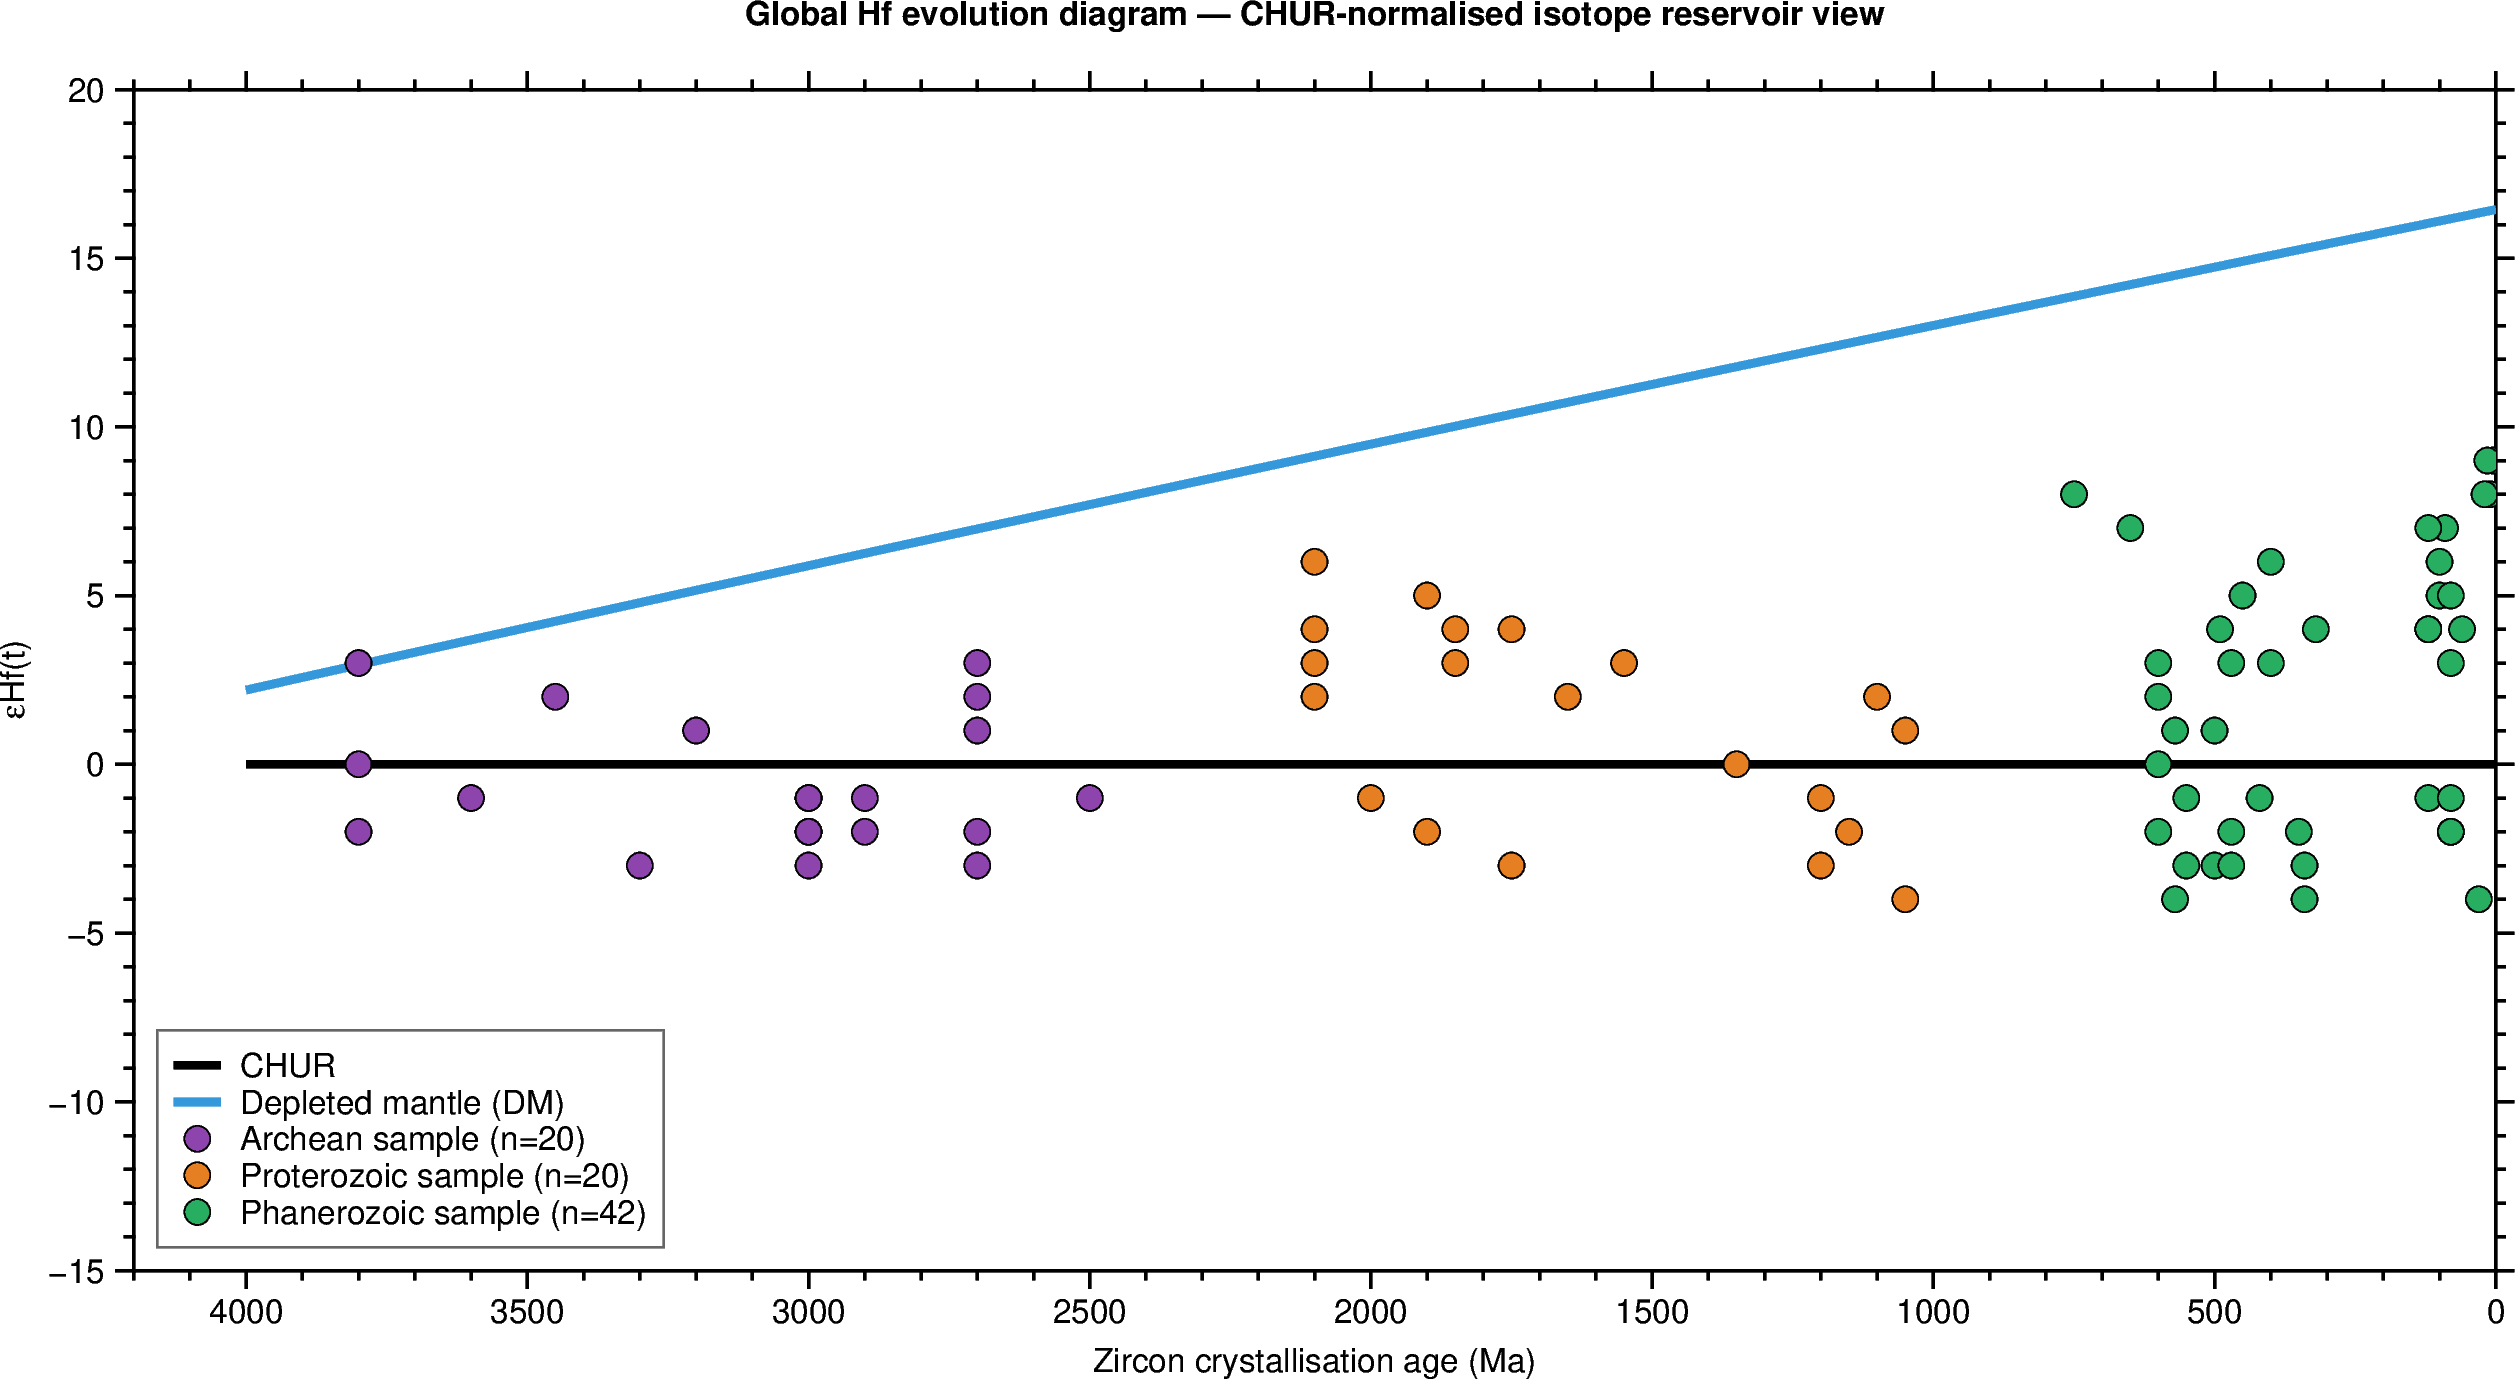

In [8]:
def epsilon_hf_at_time(hf177_today, lu177_today, t_ma):
    """εHf(t) evolved forward from present-day (176Hf/177Hf, 176Lu/177Hf) values."""
    t_yr = t_ma * 1e6
    hf_ratio_t   = hf177_today - lu177_today * (np.exp(LAMBDA_176LU * t_yr) - 1)
    chur_ratio_t = CHUR_176HF_177HF_TODAY - CHUR_176LU_177HF_TODAY * (np.exp(LAMBDA_176LU * t_yr) - 1)
    return 1e4 * (hf_ratio_t / chur_ratio_t - 1)

ages_line = np.linspace(0, 4000, 401)
chur_line = np.zeros_like(ages_line)
dm_line   = np.array([epsilon_hf_at_time(DM_176HF_177HF_TODAY, DM_176LU_177HF_TODAY, t)
                      for t in ages_line])

fig = pygmt.Figure()
fig.basemap(region=[0, 4200, -15, 20], projection="X-20c/10c",
            frame=["WSne+tGlobal Hf evolution diagram — CHUR-normalised isotope reservoir view",
                   "xa500f100+lZircon crystallisation age (Ma)",
                   "yaf+lεHf(t)"])

# CHUR line at 0
fig.plot(x=ages_line, y=chur_line, pen="2p,black", label="CHUR")

# DM line
fig.plot(x=ages_line, y=dm_line, pen="2p,#3498db", label="Depleted mantle (DM)")

# Sample scatter — colour by tectonic era category (approximate colouring: Archean/Prot/Phan)
def era_colour(age):
    if age >= 2500: return "#8e44ad"  # Archean cratons
    if age >= 1000: return "#e67e22"  # Proterozoic
    return "#27ae60"                   # Phanerozoic

df["_era_colour"] = df["zircon_age_ma"].apply(era_colour)
for era, cname, label in [(3000, "#8e44ad", "Archean sample"),
                           (1500, "#e67e22", "Proterozoic sample"),
                           (500,  "#27ae60", "Phanerozoic sample")]:
    if era >= 2500: sub = df[df["zircon_age_ma"] >= 2500]
    elif era >= 1000: sub = df[(df["zircon_age_ma"] >= 1000) & (df["zircon_age_ma"] < 2500)]
    else: sub = df[df["zircon_age_ma"] < 1000]
    if len(sub) == 0: continue
    fig.plot(x=sub["zircon_age_ma"], y=sub["epsilon_hf_t"],
             style="c0.22c", fill=cname, pen="0.3p,black",
             label=f"{label} (n={len(sub)})")

fig.legend(position="JBL+jBL+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1100)


### How to read the Hf evolution diagram

- **Every sample plots between CHUR (black) and DM (blue).** No natural sample sits *above* the DM line, because that would require a source more depleted than the depleted mantle — physically impossible. Samples *below* CHUR are strongly reworked continental crust.
- **Archean juvenile samples** — Superior Abitibi, Pilbara Marble Bar, Slave Yellowknife — plot right on the DM line at 2700-3500 Ma. These record the birth of continental crust.
- **Neoproterozoic Arabian-Nubian samples** — plot high on the diagram at 600-800 Ma, close to DM. The classic juvenile Neoproterozoic province.
- **Grenville, Variscan, Delamerian** — plot low (negative εHf) at 1050-500 Ma. Strongly reworked evolved crust.
- **Cordilleran arcs (Sierra Nevada, Peninsular Ranges, Andean, Papuan, Vanuatu)** — high εHf near-DM at 0-200 Ma. Juvenile arc extraction.

**The vertical spread at any age** measures the diversity of crustal reservoirs feeding new zircons at that time. Compare the Archean spread (mostly juvenile) with the Grenville-age spread (Bimodal juvenile + evolved) — this is one of the classic observations tying isotope compilations to the supercontinent cycle.


## Extend this

- **Load a real compilation.** Belousova et al. (2010) supplementary tables (\~13k Hf-in-zircon analyses), or Roberts & Spencer (2015) database. Drop into `data/hf_nd_isotopes/` in the same schema and the notebook picks it up.
- **Add Sr and Pb isotopes.** ⁸⁷Sr/⁸⁶Sr(t) and ²⁰⁷Pb/²⁰⁶Pb tell complementary stories — Sr tracks the sedimentary vs mantle contribution, Pb tracks the mantle vs upper-crust vs lower-crust source. Combine into a multi-isotope terrane map.
- **Vary the paleo-age window.** Change `PALEO_WINDOW_MIN_MA / MAX_MA / PALEO_TARGET_MA` to isolate specific crustal-generation events: 1050-1250 Ma at 1100 Ma for Grenville-age crust, 1750-1950 Ma at 1850 Ma for Trans-Hudson / Yavapai juvenile crust, 90-120 Ma at 100 Ma for the Cordilleran juvenile flare-up.
- **Compare with the zircon suite (T21-T24).** The Wu 2023 detrital / igneous / metamorphic zircon compilation used in T21-T24 has age but no isotope information. If you supplement it with the Belousova / Puetz Hf database (or the Wu 2023 supplement Table S3), you can colour those T21-T24 maps by εHf and see the tectonic-setting patterns Jian et al. (2022) discuss.
- **Add crustal-domain polygons.** Draw the mapped extents of major Archean cratons (Bleeker 2003 catalog) and colour them by median T_DM within the polygon — a truly polygon-based terrane map.

## Related notebooks

- **T21-T24** — Wu 2023 zircon compilation (age only, no isotopes). T25 is the isotope-companion.
- **T52** — Ophiolite emplacement paleo-map — a different point-catalog on the same paleogeographic reconstruction infrastructure.
- **T60** — PBDB paleobiogeography — same per-sample-age reconstruction pattern.

## Sources

- Belousova, E.A., Kostitsyn, Y.A., Griffin, W.L., Begg, G.C., O'Reilly, S.Y. & Pearson, N.J. (2010). The growth of the continental crust: Constraints from zircon Hf-isotope data. *Lithos* 119, 457-466. doi:10.1016/j.lithos.2010.07.024.
- Roberts, N.M.W. & Spencer, C.J. (2015). The zircon archive of continent formation through time. *Geological Society, London, Special Publications* 389, 197-225. doi:10.1144/SP389.14.
- Bennett, V.C. & DePaolo, D.J. (1987). Proterozoic crustal history of the western United States as determined by neodymium isotopic mapping. *GSA Bulletin* 99(5), 674-685.
- Griffin, W.L., Pearson, N.J., Belousova, E., Jackson, S.E., van Achterbergh, E., O'Reilly, S.Y. & Shee, S.R. (2000). The Hf isotope composition of cratonic mantle: LAM-MC-ICPMS analysis of zircon megacrysts in kimberlites. *Geochimica et Cosmochimica Acta* 64(1), 133-147.
- Bouvier, A., Vervoort, J.D. & Patchett, P.J. (2008). The Lu-Hf and Sm-Nd isotopic composition of CHUR: Constraints from unequilibrated chondrites and implications for the bulk composition of terrestrial planets. *EPSL* 273, 48-57.
- Payne, J.L., Barovich, K.M. & Hand, M. (2006). Provenance of metasedimentary rocks in the northern Gawler Craton, Australia: Implications for Palaeoproterozoic reconstructions. *Precambrian Research* 148, 275-291.
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. doi:10.1002/gdj3.146.
